In [1]:
from math import pi

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

from fluxoniumcr import DATA_DIR
from fluxoniumcr.plotting.cookbook import colorline, plot_triangle


plt.style.use("fluxoniumcr.plotting.paper")

# Load data

In [2]:
datasets = []

for p in (DATA_DIR/"three_cases"/"EJ=4.0,EC=1.0,EL=1.0").iterdir():
    if p.is_dir(): continue
    datasets.append(xr.load_dataset(p))

datasets = sorted(
    datasets,
    key=lambda d: d.drive_frequency,
)

# Plotting functions

In [7]:
def plot_delta_polarization(
        ax,
        polarizations,
        optimal_amplitude=None,
        optimal_amplitude_first=None,
        p0_series=None,
        p1_series=None,
) -> None:
    amplitude = polarizations.amplitude
    delta_p = polarizations.sel(qubit_label=1) - polarizations.sel(qubit_label=0)
    
    ax.plot(
        amplitude.data/amplitude.plot_unit,
        delta_p.data,
        c='C0',
    )
    
#     for which, Ω in enumerate([optimal_amplitude, optimal_amplitude_first]):
    for which, Ω in enumerate([optimal_amplitude]):
        if Ω is None: continue
        iopt = amplitude.searchsorted(Ω)
        delta_popt = delta_p[iopt]
        ax.plot(
            Ω/amplitude.plot_unit,
            delta_popt,
            marker=mpl.markers.MarkerStyle('*', joinstyle='miter'),
            markersize=8,
            markerfacecolor=[None, 'white'][which],
            c='C0',
            zorder=2,
        )
        ax.axvline(
            Ω/amplitude.plot_unit,
            ls=['--', ':'][which],
            zorder=-1,
            c='C9',
        )

    if p0_series is not None and p1_series is not None:
        delta_p_series = p1_series - p0_series
        ax.plot(
            amplitude.data/amplitude.plot_unit,
            np.polynomial.Polynomial(delta_p_series.data)(amplitude.data),
            ls='--',
            c='C0',
        )
    
    ax.set_xlim(
        amplitude.min()/amplitude.plot_unit,
        amplitude.max()/amplitude.plot_unit,
    )
    ax.set_ylim(0.0, 1.1*delta_p.max())


def plot_error_rates(ax, error_rate) -> None:
    ax.plot(
        error_rate.amplitude.data/error_rate.amplitude.plot_unit,
        error_rate.data/error_rate.plot_unit,
        c='C1',
    )
    ax.set_ylim(0.0, 2*error_rate.min()/error_rate.plot_unit)

    
def plot_quasienergies(
        ax,
        quasienergies,
        optimal_amplitude=None,
        optimal_amplitude_first=None,
        margin_top=0.0,
        margin_bottom=0.0,
        label_adjust=None,
):
    amplitude = quasienergies.amplitude
    
    y = quasienergies.data.copy()
    yperiod = quasienergies.period
    
    y00 = y[0, 0]
    y -= y00
    y = ((y + yperiod) % (2*yperiod)) - yperiod
    y = np.unwrap(y, axis=0, period=2*yperiod)
    y += ((y00 + yperiod) % (2*yperiod)) - yperiod
    
#     if abs(y[0].mean()) > abs(y[0].mean() + yperiod):
#         y += yperiod
#     elif abs(y[0].mean()) > abs(y[0].mean() - yperiod):
#         y -= yperiod
 
    roi_top = y[:, [0, 1]].max()
    roi_bottom = y[:, [0, 1]].min()
    roi_height = roi_top - roi_bottom
    ylim_top = roi_top + margin_top * roi_height
    ylim_bottom = roi_bottom - margin_bottom * roi_height
    
    ytick_spacing = 0.2
    if ((ylim_top - ylim_bottom)/quasienergies.plot_unit)/ytick_spacing > 8:
        ytick_spacing = 0.5
    
    ylim_top = quasienergies.plot_unit * (
        ytick_spacing
        * np.floor(ylim_top/quasienergies.plot_unit/ytick_spacing)
        + ytick_spacing/2
    )
    ylim_bottom = quasienergies.plot_unit * (
        ytick_spacing
        * np.ceil(ylim_bottom/quasienergies.plot_unit/ytick_spacing)
        - ytick_spacing/2
    )
    ax.yaxis.set_major_locator(mpl.ticker.MultipleLocator(ytick_spacing))    
    
    for k in range(-10, 10):
        for i in range(y.shape[1])[::-1]:
            yik = y[:, i] + k*yperiod
            if yik.min() > ylim_top or yik.max() < ylim_bottom:
                continue
                
            if k % 2 == 0:
                c = f'C{i+2}'
                zorder = 1
            else:
                c = 'lightgray'
                zorder = -2
            
            kwargs = {}
            if c != 'lightgray' and i in {0, 1}:
                kwargs['lw'] = 1.3
            
            ax.plot(
                amplitude.data/amplitude.plot_unit,
                yik/quasienergies.plot_unit,
                c=c,
                zorder=zorder,
                **kwargs,
            )
    
    label_adjust = label_adjust or {}
    for i in range(y.shape[1]):
        offset_x, offset_k, va = label_adjust.get(i, (0.05, 0, 'center'))
        offset_index = amplitude.searchsorted(offset_x * amplitude.plot_unit)
        ax.annotate(
            f"{i}",
            (
                amplitude[offset_index]/amplitude.plot_unit,
                (y[offset_index, i] + 2*offset_k*yperiod)/quasienergies.plot_unit,
            ),
            (
                2 if amplitude.data[offset_index] == 0 else 0,
#                 -1 if va == 'top' else 1,
                0.0,
            ),
            textcoords='offset points',
            fontsize=mpl.rcParams["xtick.labelsize"],
            fontweight='bold' if i in {0, 1} else 'normal',
            c=f"C{i+2}",
            ha='center',
            va=va,
            zorder=1,
            bbox=dict(boxstyle='circle', color='white', pad=0.0),
        )
        
    star_marker = mpl.markers.MarkerStyle('*', joinstyle='miter')
    
#     for which, Ω in enumerate([optimal_amplitude, optimal_amplitude_first]):
    for which, Ω in enumerate([optimal_amplitude]):
        if Ω is None: continue
        iopt = amplitude.searchsorted(Ω)
        ax.plot(
            Ω/amplitude.plot_unit,
            y[iopt, 0]/quasienergies.plot_unit,
            marker=star_marker,
            markersize=8,
            markerfacecolor=[None, 'white'][which],
            c='C2',
            zorder=2,
        )
        ax.plot(
            Ω/amplitude.plot_unit,
            y[iopt, 1]/quasienergies.plot_unit,
            marker=star_marker,
            markersize=8,
            markerfacecolor=[None, 'white'][which],
            c='C3',
            zorder=2,
        )
        ax.axvline(
            Ω/amplitude.plot_unit,
            ls=['--', ':'][which],
            zorder=-1,
            c='C9',
        )
        
    ax.set_xlim(
        amplitude.min()/amplitude.plot_unit,
        amplitude.max()/amplitude.plot_unit,
    )
    ax.set_ylim(
        ylim_bottom/quasienergies.plot_unit,
        ylim_top/quasienergies.plot_unit,
    )


def plot_quasienergies_avoided_crossing(
        ax,
        quasienergies,
        avgenergies,
        axins_bounds,
        cmap=None,
):
    amplitude = max(quasienergies.coords.values(), key=len)
    
    y = quasienergies.data.copy()
    yperiod = quasienergies.period
    
    y0 = y[:, [0]]
    y -= y0
    y = ((y + yperiod/2) % (yperiod)) - yperiod/2
    y = np.unwrap(y, axis=0, period=yperiod)
    y += y0

    iac = np.diff(y, axis=1).argmin()
    y += np.round((np.mean(ax.get_ybound()) - y[iac])/yperiod)*yperiod

    axins = ax.inset_axes(
        axins_bounds,
        xlim=(
            amplitude.min()/amplitude.plot_unit,
            amplitude.max()/amplitude.plot_unit
        ),
        ylim=(
            y.min()/quasienergies.plot_unit,
            y.max()/quasienergies.plot_unit,
        ),
        xticks=[],
        yticks=[],
    )
    
    colorline(
        axins,
        amplitude.data/amplitude.plot_unit,
        y[:, 0]/quasienergies.plot_unit,
        avgenergies[:, 0].data/avgenergies.plot_unit,
        cmap=cmap,
    )
    colorline(
        axins,
        amplitude.data/amplitude.plot_unit,
        y[:, 1]/quasienergies.plot_unit,
        avgenergies[:, 1].data/avgenergies.plot_unit,
        cmap=cmap,
    )
    
    gap_size = np.ptp(y[iac])
    axins.annotate(
        f"{gap_size*1e3/quasienergies.plot_unit:.1f} MHz",
        (1, 1),
        (-2, -2),
        fontsize=mpl.rcParams["xtick.labelsize"],
        xycoords='axes fraction',
        textcoords='offset points',
        ha='right',
        va='top',
    )
    
    plot_triangle(
        axins,
        amplitude.data[iac]/amplitude.plot_unit,
        y[iac].max()/quasienergies.plot_unit,
        size=5,
        direction="down",
    )
    plot_triangle(
        axins,
        amplitude.data[iac]/amplitude.plot_unit,
        y[iac].min()/quasienergies.plot_unit,
        size=5,
        direction="up",
    )

    ax.indicate_inset_zoom(axins, edgecolor="black")

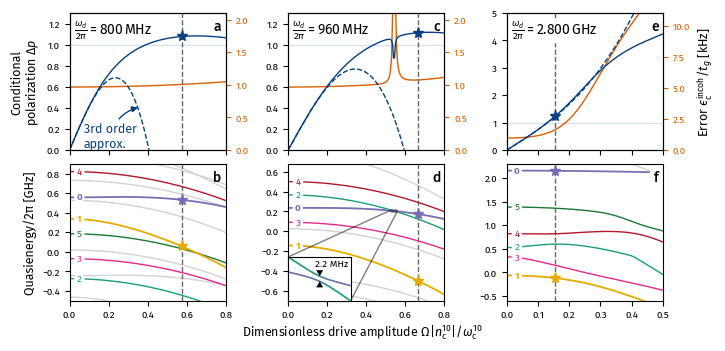

In [10]:
fig, axs = plt.subplots(2, 3, figsize=(179/25.4, 85/25.4), sharex='col')

for i, ax1 in enumerate(axs[0]):
    dataset = datasets[i]
    
    ax1.patch.set_visible(False)
    ax2 = ax1.twinx()
    ax1.set_zorder(10)
    ax2.tick_params(axis='y', colors='C1')
        
    if i == 0:
        plot_delta_polarization(
            ax1,
            dataset.polarization,
            dataset.optimal_amplitude,
            None,
            dataset.p0_series,
            dataset.p1_series,
        )
        ax1.annotate(
            "3rd order\napprox.",
            (0.365, 0.41),
            (-41, -11),
            textcoords='offset points',
            ha='left',
            va='top',
            c='C0',
            arrowprops=dict(
                shrinkA=0.1,
                connectionstyle="arc3,rad=-0.3",
                arrowstyle="-|>",
                joinstyle="miter",
                capstyle="butt",
                ec='C0',
            ),
        )
    elif i == 1:
        p = dataset.polarization.copy()
        
        # Mask out data with drive amplitude around +/- 0.05 the avoided crossing.
        mask = (
            (p.amplitude >= dataset.ac_amplitude - 0.05)
            & (p.amplitude <= dataset.ac_amplitude + 0.05)
        )
        p[mask] = np.nan
        
        plot_delta_polarization(
            ax1,
            p,
            dataset.optimal_amplitude,
            dataset.optimal_amplitude_first,
            dataset.p0_series,
            dataset.p1_series,
        )
    else:
        plot_delta_polarization(
            ax1,
            dataset.polarization,
            dataset.optimal_amplitude,
            None,
            dataset.p0_series,
            dataset.p1_series,
        )
    
    plot_error_rates(ax2, dataset.error_rate)
    
    ax1.tick_params(axis='x', direction='out', labelbottom=False)
    
    if i in (0, 1):
        yticks = np.linspace(0, 1.2, 7)
        ax1.set_yticks(yticks, ["0.0", *map("{:.1f}".format, yticks[1:])])
        ax1.set_ylim(0, 1.3)
        ax2.set_yticks(np.linspace(0, 2.0, 5))
        ax2.set_ylim(0, 2.1)
    elif i == 2:
        ax1.set_ylim(0, 5)
        ax2.set_yticks(np.linspace(0, 10.0, 5))
        ax2.set_ylim(0, 11)
    
    ax1.axhline(1.0, c='C0', alpha=0.15, zorder=0)
    
    if i == 0:
        ax1.set_ylabel("Conditional\npolarization $\\Delta p$")
    elif i == 2:
        ax2.set_ylabel(r"Error $ϵ^\mathrm{incoh}_\mathrm{c}/t_g$ [kHz]")

        
for i, ax in enumerate(axs[1]):
    dataset = datasets[i]
    if i == 0:
        plot_quasienergies(
            ax,
            dataset.quasienergy[:, :6],
            dataset.optimal_amplitude,
            None,
            margin_top=0.3,
            margin_bottom=0.0,
            label_adjust={2: (0.05, -1, 'center')}
        )
        ax.set_xlim(0, 0.8)
        ax.set_ylim(-0.5, 0.9)
        ax.set_yticks(np.linspace(-0.4, 0.8, 7))
    if i == 1:
        plot_quasienergies(
            ax,
            dataset.quasienergy[:, :6],
            dataset.optimal_amplitude,
            dataset.optimal_amplitude_first,
            margin_top=0.3,
            margin_bottom=0.0,
            label_adjust={
                5: (0.245, -1, 'top')
            }
        )
        plot_quasienergies_avoided_crossing(
            ax,
            dataset.quasienergy_around_ac.sel(label=[0, 2]),
            dataset.avgenergy_around_ac.sel(label=[0, 2]),
            axins_bounds=[0.0, 0.0, 0.4, 0.32],
            cmap=mpl.colors.LinearSegmentedColormap.from_list("", ["C2", "C4"]),
        )
        ax.set_xlim(0, 0.8)
        ax.set_ylim(-0.7, 0.68)
        ax.set_yticks(np.linspace(-0.6, 0.6, 7))
    if i == 2:
        plot_quasienergies(
            ax,
            dataset.quasienergy[:, :6],
            dataset.optimal_amplitude,
            None,
            margin_top=0.1,
            margin_bottom=0.0,
            label_adjust={
                0: (0.05*5/8, 0, 'center'),
                1: (0.05*5/8, 0, 'center'),
                2: (0.05*5/8, 0, 'center'),
                3: (0.05*5/8, 0, 'center'),
                4: (0.05*5/8, 0, 'center'),
                5: (0.05*5/8, 0, 'center'),
            }
        )
        ax.set_xlim(0, 0.5)
        ax.set_ylim(-0.6, 2.3)


fig.supxlabel(r"Dimensionless drive amplitude $\Omega |n_\mathrm{c}^{10}|/\omega_\mathrm{c}^{10}$")

axs[1, 0].set_ylabel("Quasienergy/2π [GHz]")

labels = np.array([
    ["a", "c", "e"],
    ["b", "d", "f"]
])

for ax, label in zip(axs.ravel(), labels.ravel()):
    if label in {"f"}:
        bbox = dict(boxstyle='square', color='white', pad=0.3)
#         bbox = None
    else:
        bbox = None
        
    annotation = ax.annotate(
        label,
        (1, 1),
        (-3, -4.7),
        xycoords='axes fraction',
        textcoords='offset points',
        fontweight='medium',
        fontsize=10,
        ha="right",
        va="top",
        bbox=bbox,
        zorder=1,
    )
    annotation.set_clip_box(ax.get_window_extent())
    annotation.set_clip_on(True)


for dataset, ax in zip(datasets, axs[0]):
    drive_frequency = dataset.drive_frequency
    if drive_frequency > 1 * 2*pi:
        freq_text = f"{drive_frequency/(2*pi):.3f}\\,\\mathrm{{GHz}}"
    else:
        freq_text = f"{1000*drive_frequency/(2*pi):.0f}\\,\\mathrm{{MHz}}"
        
    annotation = ax.annotate(
        f"$\\frac{{\\omega_d}}{{2\\pi}}={freq_text}$",
        (0, 1),
        (3, -4.7),
        xycoords='axes fraction',
        textcoords='offset points',
        fontweight='normal',
        fontsize=10,
        ha="left",
        va="top",
        bbox=dict(boxstyle='square', color='white', pad=0.0),
        zorder=1,
    )
    annotation.set_clip_box(ax.get_window_extent())
    annotation.set_clip_on(True)


plt.subplots_adjust(
    left=0.085,
    right=0.927,
    top=0.99,
    bottom=0.13,
    wspace=0.4,
    hspace=0.10,
)

plt.savefig("three_cases.pdf")